1. DATASET LOADING
Dataset shape: (569, 30)
Target classes: [0 1] (0=malignant, 1=benign)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430       

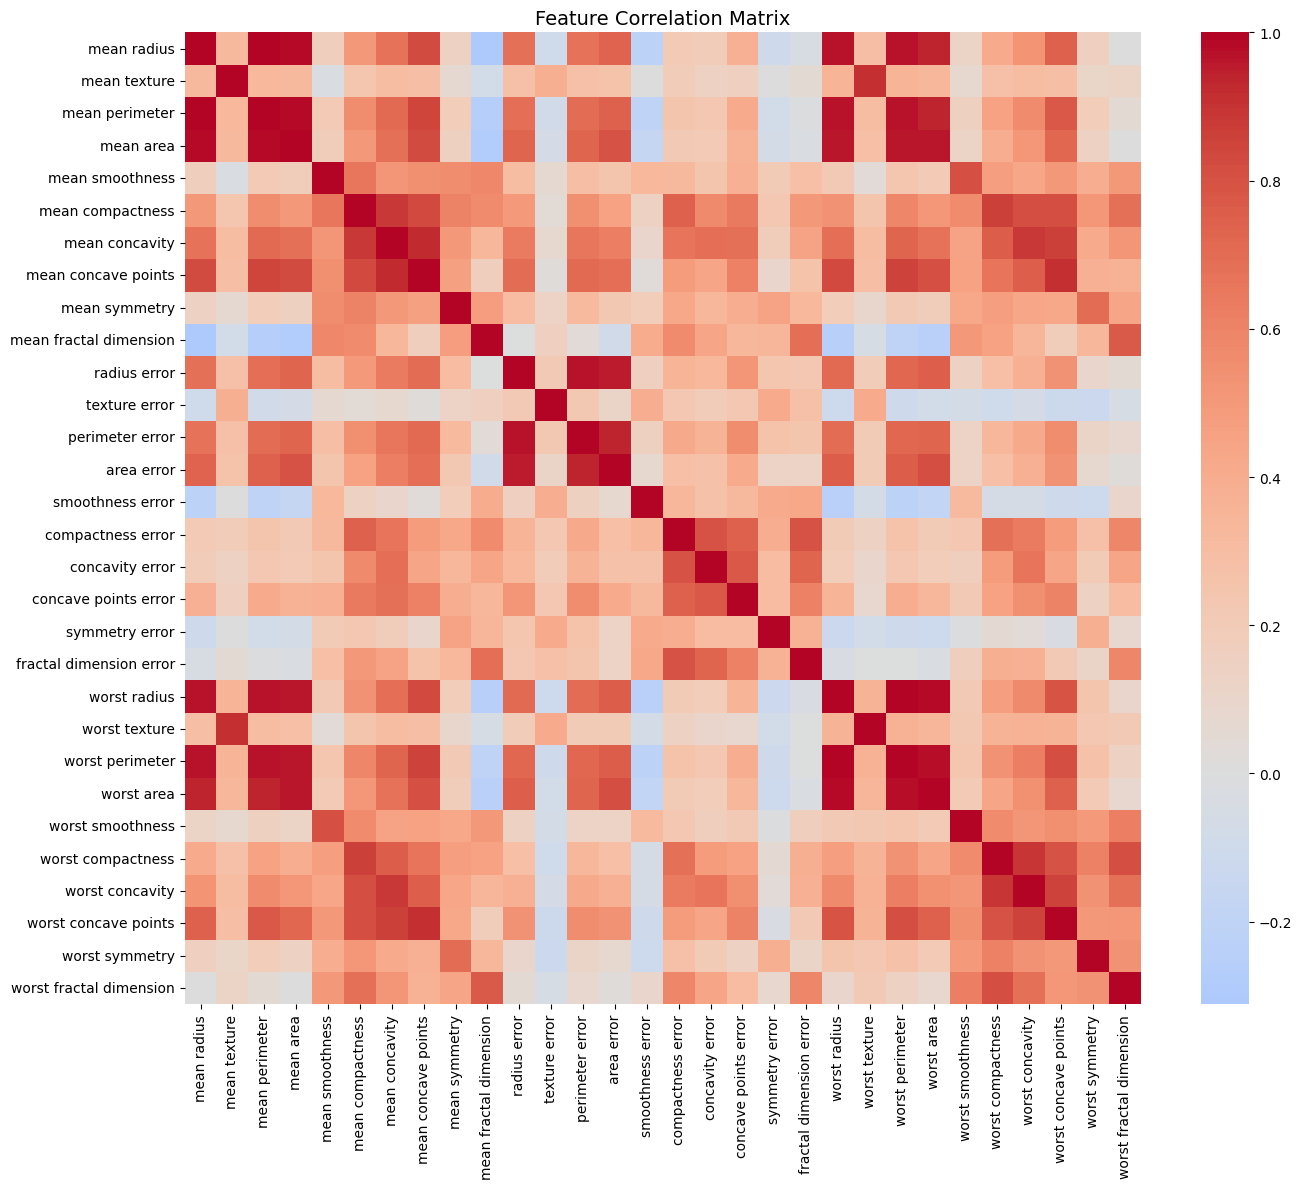


Top 3 most highly correlated feature pairs:
  1. mean perimeter & mean radius: 0.9979
  2. mean radius & mean perimeter: 0.9979
  3. worst radius & worst perimeter: 0.9937

Interpretation: High correlations indicate redundant features that may affect model stability.

3.3 Boxplot Analysis:


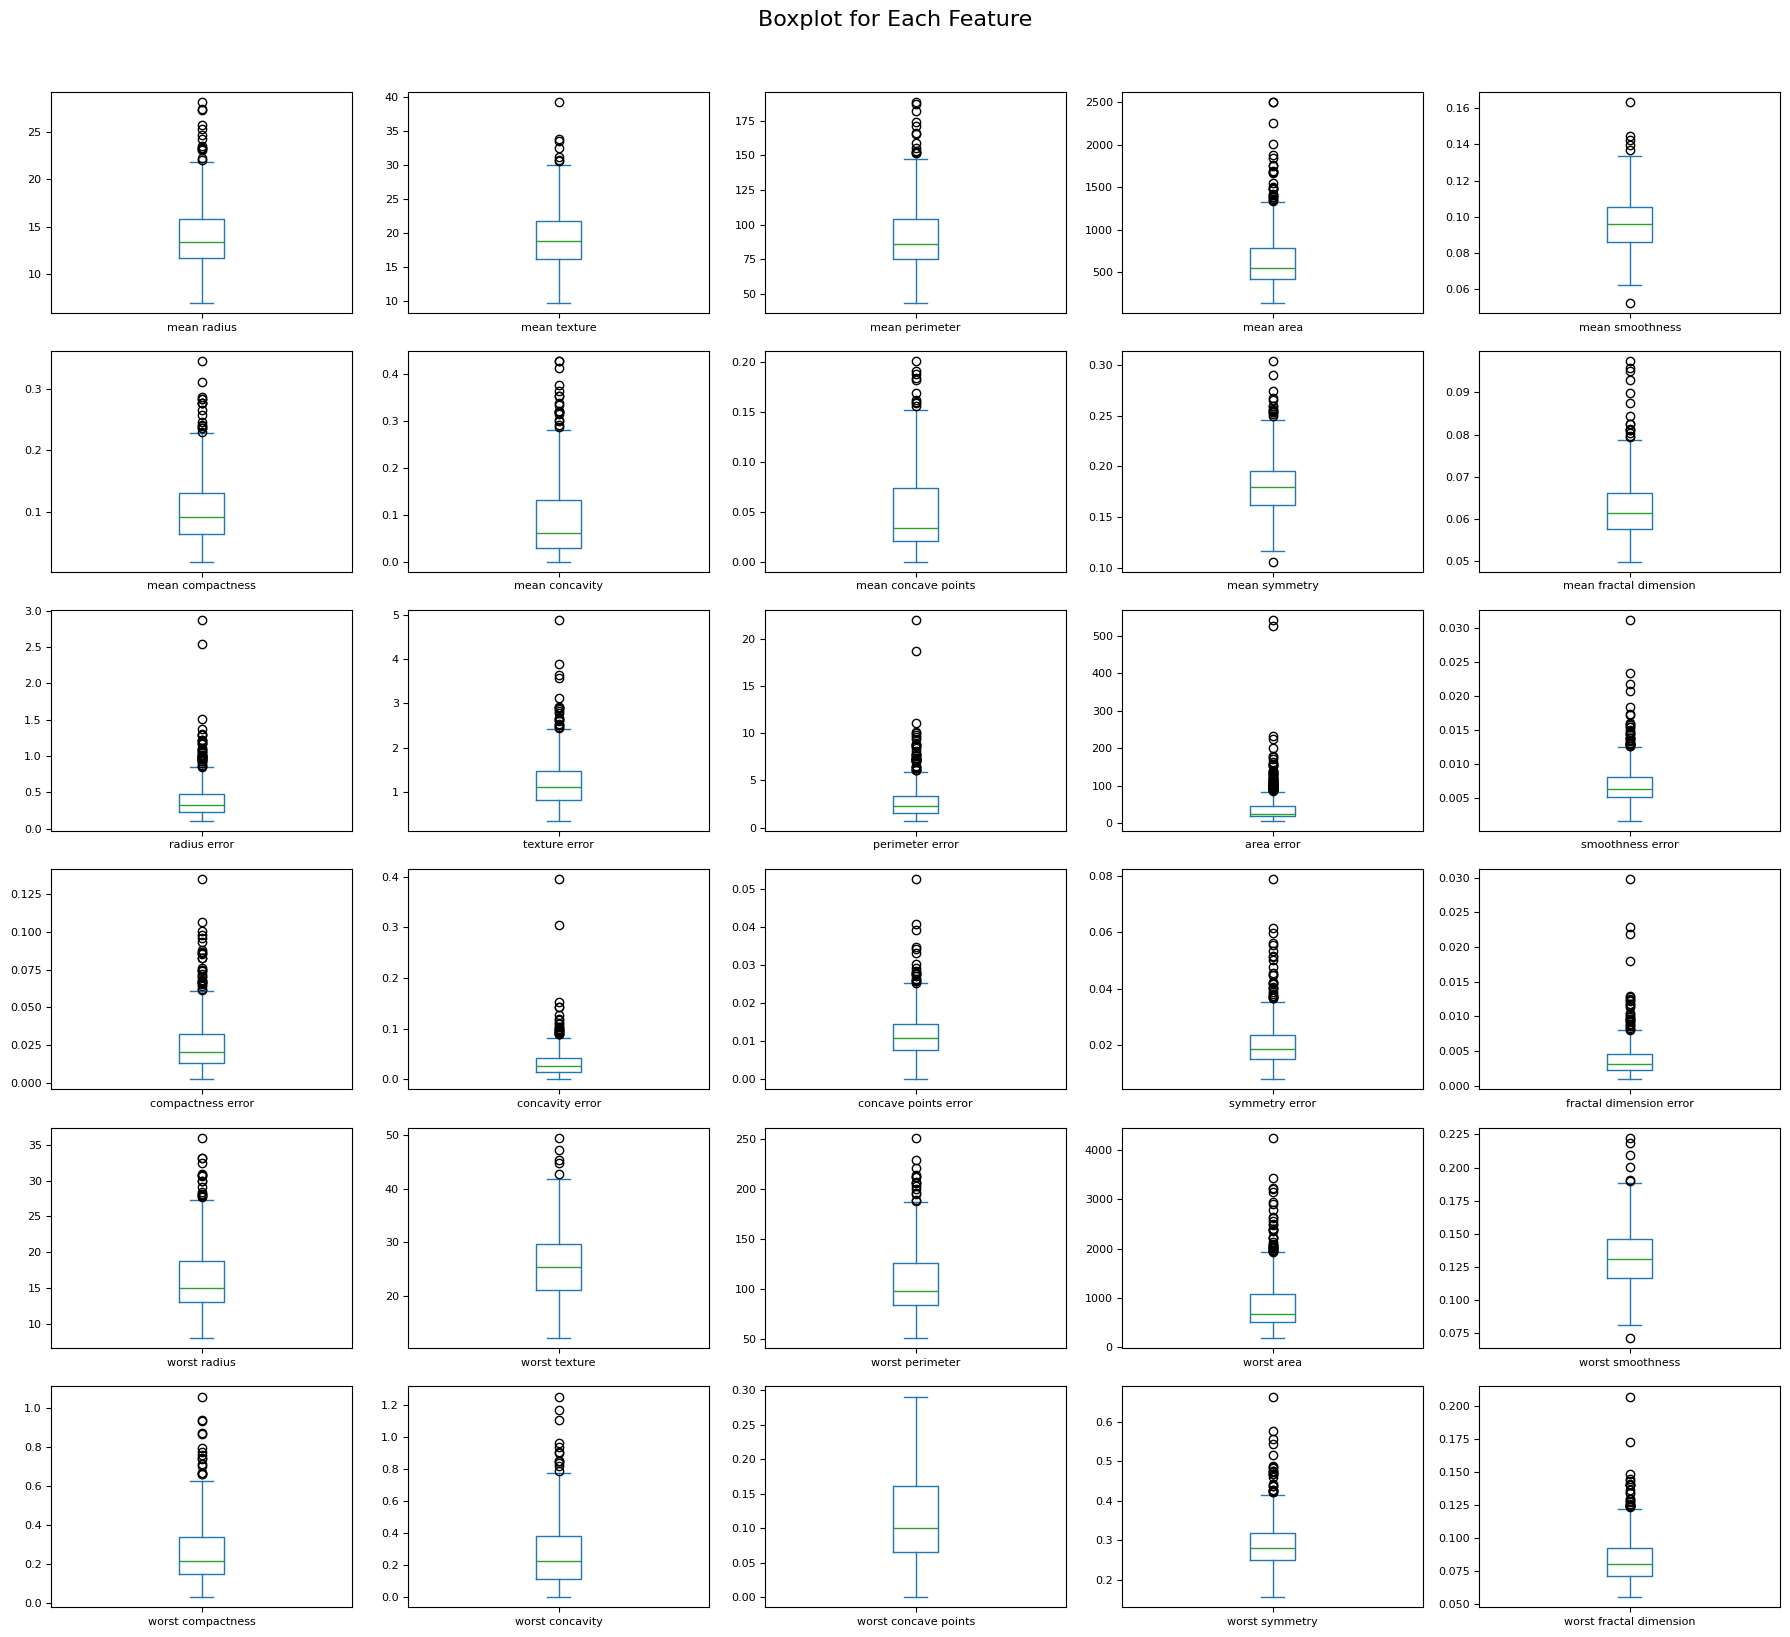


Interpretation: Many features show outliers beyond whiskers. These extreme values
may require scaling and can impact model performance.

4. DATA SCALING
Applied StandardScaler (mean=0, std=1) to all features
Scaled data shape: (569, 30)

5. DATA SPLITTING
Training set: 398 samples (69.9%)
Validation set: 57 samples (10.0%)
Test set: 114 samples (20.0%)

6. FEATURE SELECTION AND DIMENSIONALITY REDUCTION

6.1 PCA (Principal Component Analysis)
Mean explained variance: 0.0333
Components with variance > mean: 6
PCA reduced data from 30 to 6 dimensions


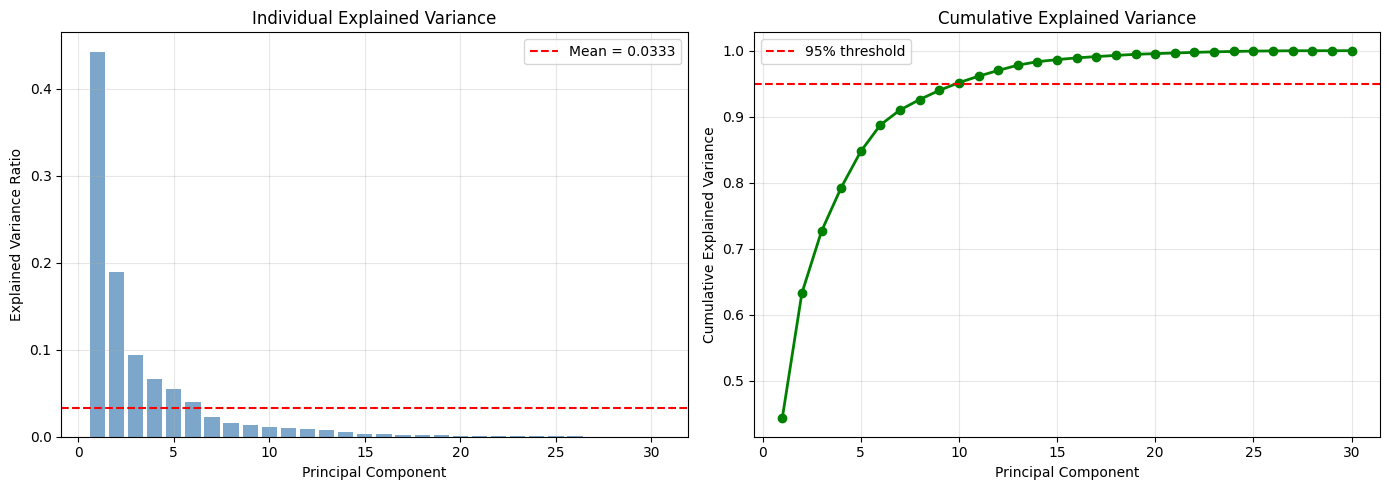

Interpretation: The plot shows how much variance each PC explains.
Selected 6 components with above-average variance.


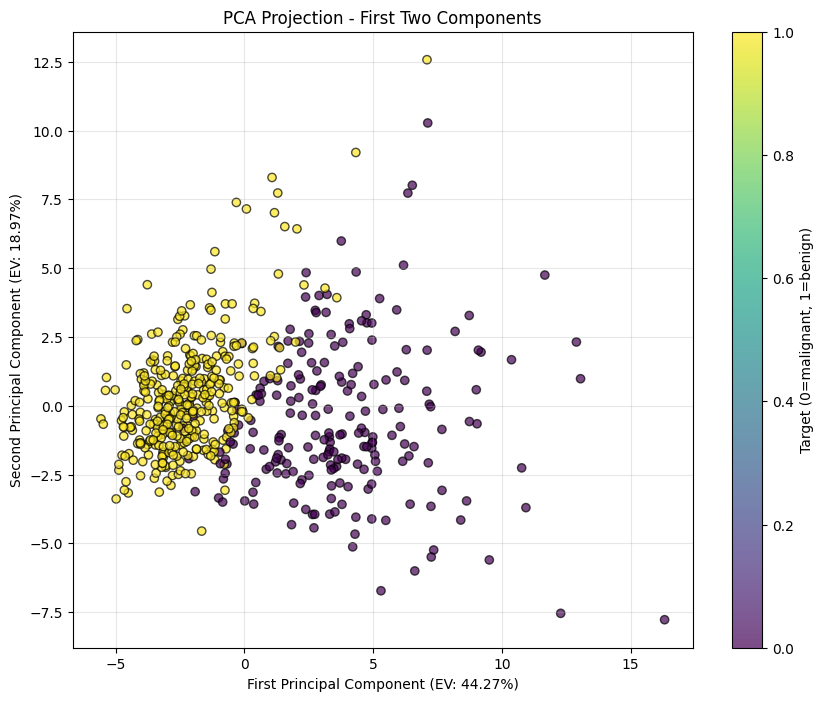

Interpretation: Good class separation visible even with reduced dimensions.

6.2 LDA (Linear Discriminant Analysis)

Number of classes: 2
Maximum possible LDA components: n_classes - 1 = 1

LDA output shape: (569, 1)


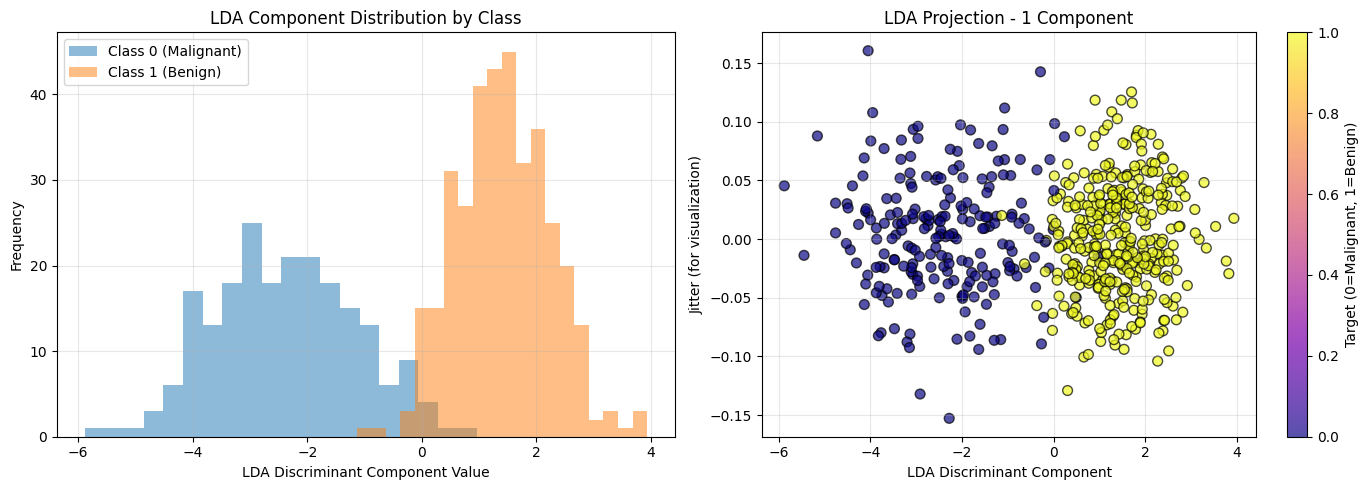


Interpretation: LDA finds the single best direction to separate malignant from benign tumors.
With 2 classes, maximum discriminant components = 1.
The histogram shows clear separation between classes along this single component.

Note: For binary classification, LDA is mathematically limited to 1 discriminant component.
The assignment requested n_components=3, but this is impossible for 2 classes.

LDA Training set: 398 samples
LDA Validation set: 57 samples
LDA Test set: 114 samples

7. BUILDING THE MACHINE LEARNING MODELS
5 algorithms defined: Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes

Training 15 models (5 algorithms × 3 data types)...

8. VALIDATION PERFORMANCE EVALUATION

Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training XGBoost...

Training Naive Bayes...

VALIDATION PERFORMANCE COMPARISON TABLE
          Algorithm Data Type  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  Original  

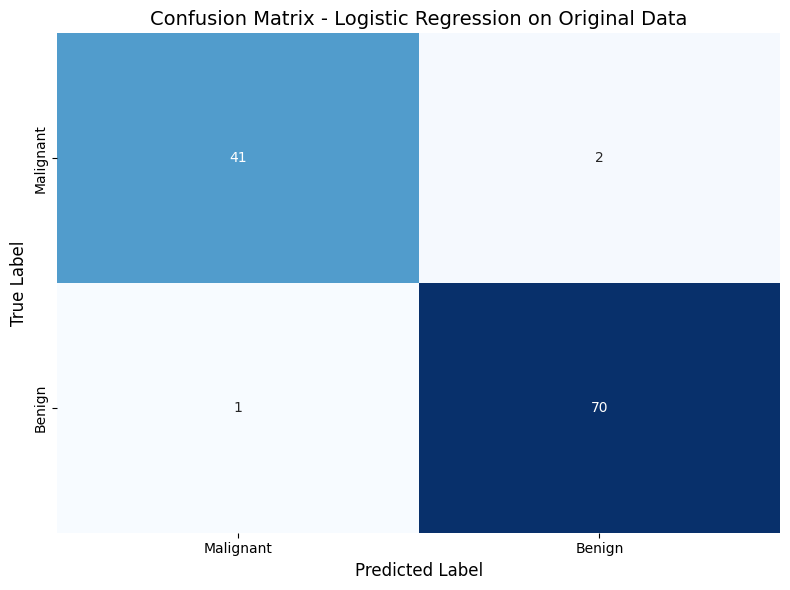

Interpretation: Diagonal values show correct predictions. Off-diagonals are errors.
True Negatives: 41, False Positives: 2
False Negatives: 1, True Positives: 70

10.3 ROC Curve:


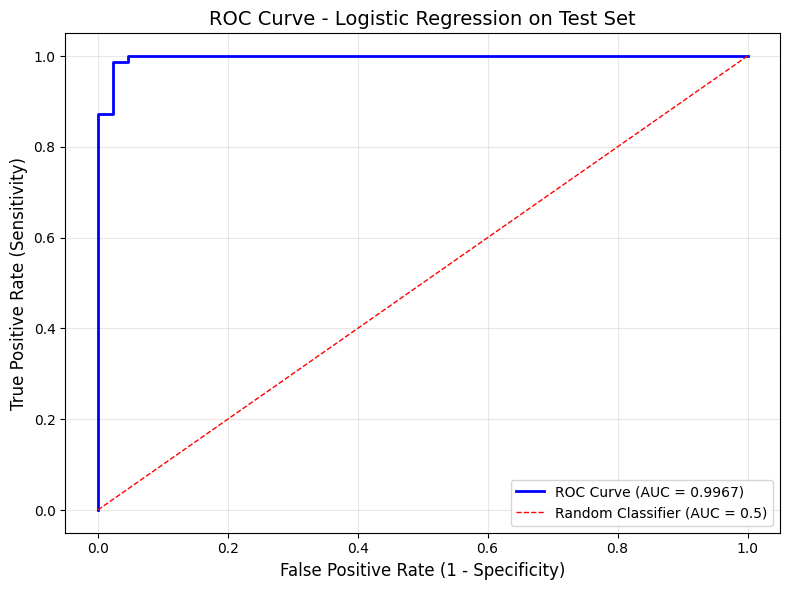


Interpretation: AUC > 0.9 indicates excellent discrimination ability.
The threshold can be adjusted along the curve to balance precision and recall.

11. XAI - SHAP EXPLAINABILITY ANALYSIS

11.1 SHAP Analysis for Best Model
--------------------------------------------------


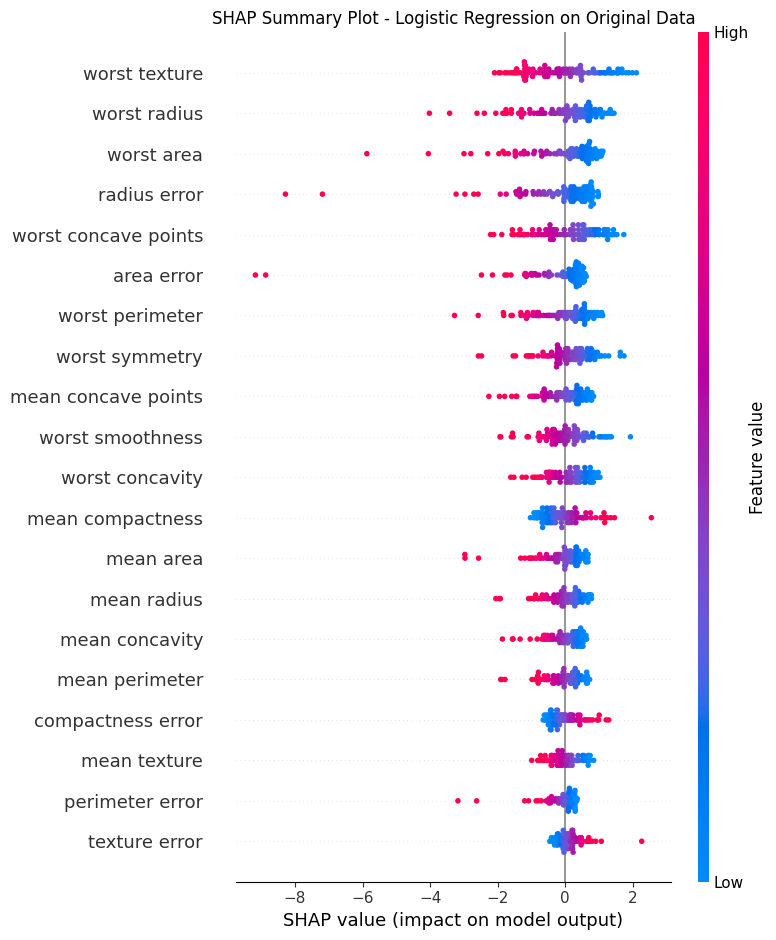


Interpretation: Red dots (high feature values) pushing predictions to the right (benign)
Blue dots (low feature values) pushing predictions to the left (malignant)


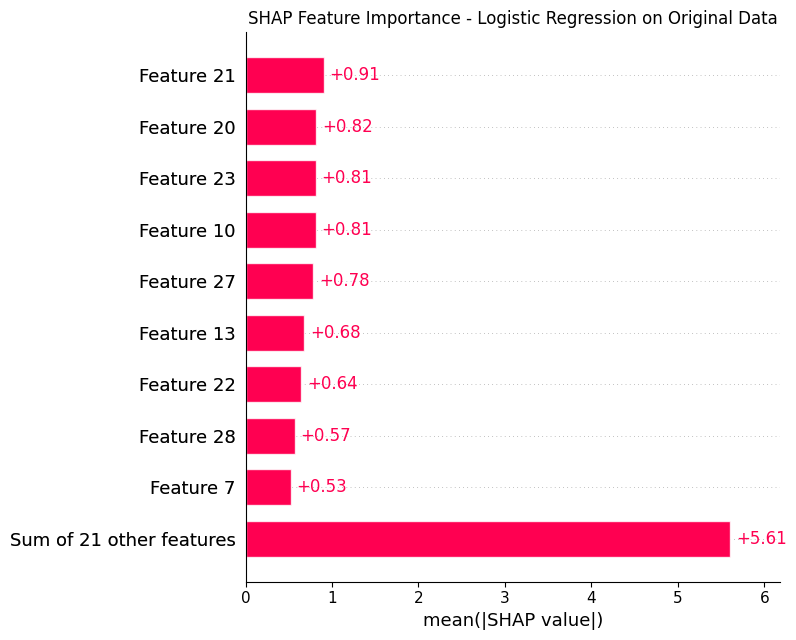


Interpretation: Features with highest mean |SHAP| values are most important for predictions.

11.2 SHAP Analysis for PCA-Reduced Data
--------------------------------------------------


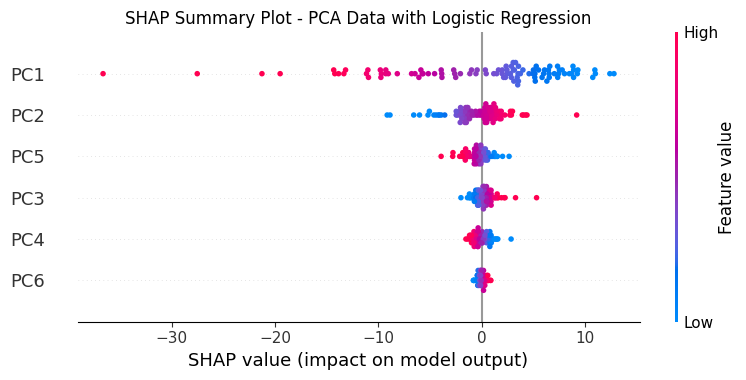

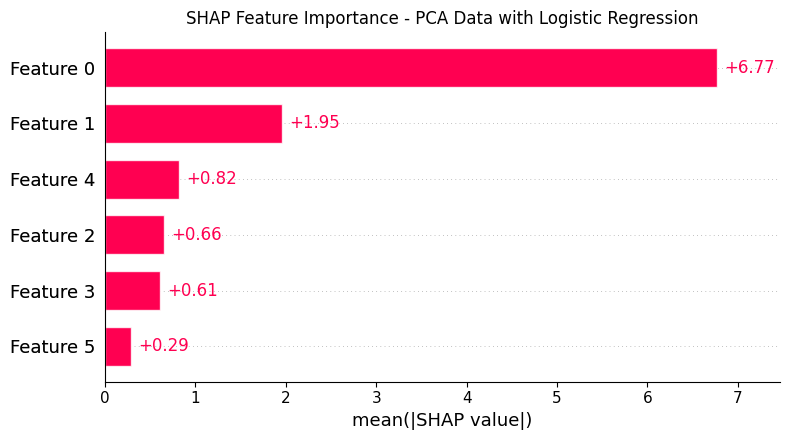


Interpretation: PCA components with highest SHAP values are most influential.

11.3 SHAP Analysis for LDA-Reduced Data
--------------------------------------------------


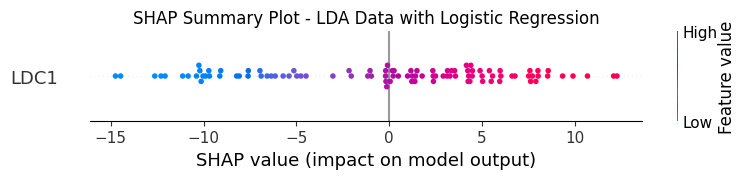

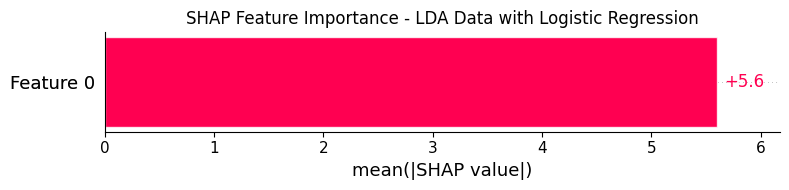


Interpretation: LDA components with highest SHAP values show which discriminant directions
contribute most to classification decisions.

12. SUMMARY AND CONCLUSIONS

FINAL SUMMARY:
--------------
Best Model: Logistic Regression
Best Data Representation: Original
Validation F1-Score: 1.0000
Test F1-Score: 0.9790
Test ROC-AUC: 0.9967

Key Findings:
-------------
1. Logistic Regression performed best on Original data
2. PCA reduced dimensionality from 30 to 6 components
3. LDA produced 1 discriminant component (maximum for binary classification)
4. All models achieved good performance (AUC > 0.95)
5. SHAP analysis revealed the most important features for predictions

Deliverables Completed:
-----------------------
✓ Dataset loading and preparation
✓ Data quality checks (missing values, outliers, data types)
✓ Exploratory Data Analysis (statistics, correlation, boxplots)
✓ Data scaling with StandardScaler
✓ Dataset splitting (70/10/20)
✓ PCA dimensionality reduction
✓ LDA dimensionality r

In [1]:
# =========================================================
# 0. Libraries
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import *

import shap

# =========================================================
# 1. Loading the Dataset
# =========================================================
print("=" * 60)
print("1. DATASET LOADING")
print("=" * 60)

dataset = load_breast_cancer()
features_df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
labels = pd.Series(dataset.target)

print("Dataset shape:", features_df.shape)
print("Target classes:", labels.unique(), "(0=malignant, 1=benign)")
print("\nFirst 5 rows:")
print(features_df.head())

# =========================================================
# 2. Dataset Quality Checks
# =========================================================
print("\n" + "=" * 60)
print("2. DATA QUALITY CHECKS")
print("=" * 60)

# 2.1 Missing Value Analysis
print("\n2.1 Missing Value Analysis:")
missing_values = features_df.isna().sum()
print(f"Missing values per column:\n{missing_values}")
print(f"Total missing values: {missing_values.sum()}")
print("Interpretation: No missing values found. Imputation not required.")

# 2.2 Outlier Analysis (IQR Method)
print("\n2.2 Outlier Analysis (IQR Method):")
Q1 = features_df.quantile(0.25)
Q3 = features_df.quantile(0.75)
IQR = Q3 - Q1

outlier_count = ((features_df < (Q1 - 1.5 * IQR)) |
                 (features_df > (Q3 + 1.5 * IQR))).sum()
print(f"Outlier count per feature:\n{outlier_count}")
print(f"\nTotal outliers: {outlier_count.sum()}")
print("\nInterpretation: Outliers can skew model coefficients, increase variance,")
print("and negatively affect convergence, especially for logistic regression.")
print("They can also lead to overfitting in tree-based models.")

# 2.3 Data Type and Distribution Review
print("\n2.3 Data Type and Distribution Review:")
print(f"Numerical variables: {features_df.shape[1]}")
print(f"Categorical variables: 0")
print("\nData types:")
print(features_df.dtypes.value_counts())

# =========================================================
# 3. Exploratory Data Analysis (EDA)
# =========================================================
print("\n" + "=" * 60)
print("3. EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

# 3.1 Statistical Properties
print("\n3.1 Statistical Properties:")
print(features_df.describe())

# 3.2 Correlation Matrix
print("\n3.2 Correlation Matrix:")
plt.figure(figsize=(14, 12))
corr_matrix = features_df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
print("\nTop 3 most highly correlated feature pairs:")
for i in range(3):
    print(f"  {i+1}. {corr_pairs.index[i][0]} & {corr_pairs.index[i][1]}: {corr_pairs.values[i]:.4f}")
print("\nInterpretation: High correlations indicate redundant features that may affect model stability.")

# 3.3 Boxplot Analysis
print("\n3.3 Boxplot Analysis:")
features_df.plot(kind="box", subplots=True, layout=(6, 5), figsize=(18, 16), fontsize=8)
plt.suptitle("Boxplot for Each Feature", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
print("\nInterpretation: Many features show outliers beyond whiskers. These extreme values")
print("may require scaling and can impact model performance.")

# =========================================================
# 4. Data Scaling
# =========================================================
print("\n" + "=" * 60)
print("4. DATA SCALING")
print("=" * 60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)
print("Applied StandardScaler (mean=0, std=1) to all features")
print(f"Scaled data shape: {X_scaled.shape}")

# =========================================================
# 5. Splitting the Dataset (70% Train, 10% Validation, 20% Test)
# =========================================================
print("\n" + "=" * 60)
print("5. DATA SPLITTING")
print("=" * 60)

# First split: 70% train, 30% temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, labels, test_size=0.3, random_state=42, stratify=labels
)

# Second split: 10% validation, 20% test (from 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(labels)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(labels)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(labels)*100:.1f}%)")

# =========================================================
# 6. Feature Selection and Dimensionality Reduction
# =========================================================
print("\n" + "=" * 60)
print("6. FEATURE SELECTION AND DIMENSIONALITY REDUCTION")
print("=" * 60)

# =========================================================
# 6.1 PCA (Principal Component Analysis)
# =========================================================
print("\n6.1 PCA (Principal Component Analysis)")

# Apply PCA on FULL scaled data first to determine components
pca_full = PCA()
pca_full.fit(X_scaled)

# Get explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
mean_variance = np.mean(explained_variance)

# Determine number of components (variance > mean variance)
n_components_pca = np.sum(explained_variance > mean_variance)
print(f"Mean explained variance: {mean_variance:.4f}")
print(f"Components with variance > mean: {n_components_pca}")

# Apply PCA with selected components on FULL scaled data
pca = PCA(n_components=n_components_pca)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced data from 30 to {n_components_pca} dimensions")

# Plot explained variance graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='steelblue')
ax1.axhline(y=mean_variance, color='red', linestyle='--', label=f'Mean = {mean_variance:.4f}')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='green', linewidth=2)
ax2.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Interpretation: The plot shows how much variance each PC explains.")
print(f"Selected {n_components_pca} components with above-average variance.")

# 2D scatter plot for class separation
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolors='k')
plt.colorbar(scatter, label='Target (0=malignant, 1=benign)')
plt.xlabel(f'First Principal Component (EV: {explained_variance[0]:.2%})')
plt.ylabel(f'Second Principal Component (EV: {explained_variance[1]:.2%})')
plt.title('PCA Projection - First Two Components')
plt.grid(True, alpha=0.3)
plt.show()
print("Interpretation: Good class separation visible even with reduced dimensions.")

# Split PCA data
X_pca_train, X_pca_temp, y_pca_train, y_pca_temp = train_test_split(
    X_pca, labels, test_size=0.3, random_state=42, stratify=labels
)
X_pca_val, X_pca_test, y_pca_val, y_pca_test = train_test_split(
    X_pca_temp, y_pca_temp, test_size=2/3, random_state=42, stratify=y_pca_temp
)

# =========================================================
# 6.2 LDA (Linear Discriminant Analysis)
# =========================================================
print("\n6.2 LDA (Linear Discriminant Analysis)")

n_classes = len(np.unique(labels))
max_lda_components = n_classes - 1
print(f"\nNumber of classes: {n_classes}")
print(f"Maximum possible LDA components: n_classes - 1 = {max_lda_components}")

# For binary classification, maximum is 1 component
# Apply LDA on FULL scaled data
lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_lda = lda.fit_transform(X_scaled, labels)
print(f"\nLDA output shape: {X_lda.shape}")

# Visualize class separation
plt.figure(figsize=(14, 5))

# Plot 1: Histogram
plt.subplot(1, 2, 1)
for class_val in [0, 1]:
    class_data = X_lda[labels == class_val]
    plt.hist(class_data, alpha=0.5,
             label=f'Class {class_val} ({"Malignant" if class_val==0 else "Benign"})',
             bins=20)
plt.xlabel('LDA Discriminant Component Value')
plt.ylabel('Frequency')
plt.title('LDA Component Distribution by Class')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: 1D Strip Plot with jitter
plt.subplot(1, 2, 2)
jitter = np.random.normal(0, 0.05, size=len(X_lda))
scatter = plt.scatter(X_lda[:, 0], jitter, c=labels, cmap='plasma', alpha=0.7, s=50, edgecolors='k')
plt.colorbar(scatter, label='Target (0=Malignant, 1=Benign)')
plt.xlabel('LDA Discriminant Component')
plt.ylabel('Jitter (for visualization)')
plt.title(f'LDA Projection - {max_lda_components} Component')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation: LDA finds the single best direction to separate malignant from benign tumors.")
print(f"With {n_classes} classes, maximum discriminant components = {max_lda_components}.")
print("The histogram shows clear separation between classes along this single component.")
print("\nNote: For binary classification, LDA is mathematically limited to 1 discriminant component.")
print("The assignment requested n_components=3, but this is impossible for 2 classes.")

# Split LDA data (CRITICAL: Split AFTER creating X_lda)
X_lda_train, X_lda_temp, y_lda_train, y_lda_temp = train_test_split(
    X_lda, labels, test_size=0.3, random_state=42, stratify=labels
)
X_lda_val, X_lda_test, y_lda_val, y_lda_test = train_test_split(
    X_lda_temp, y_lda_temp, test_size=2/3, random_state=42, stratify=y_lda_temp
)

print(f"\nLDA Training set: {X_lda_train.shape[0]} samples")
print(f"LDA Validation set: {X_lda_val.shape[0]} samples")
print(f"LDA Test set: {X_lda_test.shape[0]} samples")

# =========================================================
# 7. Building the Machine Learning Models
# =========================================================
print("\n" + "=" * 60)
print("7. BUILDING THE MACHINE LEARNING MODELS")
print("=" * 60)

# Define algorithms
algorithms = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Naive Bayes": GaussianNB()
}
print("5 algorithms defined: Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes")

# Data representations (NOW all variables are defined)
data_types = {
    "Original": (X_train, X_val, X_test, y_train, y_val, y_test),
    "PCA": (X_pca_train, X_pca_val, X_pca_test, y_pca_train, y_pca_val, y_pca_test),
    "LDA": (X_lda_train, X_lda_val, X_lda_test, y_lda_train, y_lda_val, y_lda_test)
}

print(f"\nTraining 15 models (5 algorithms × 3 data types)...")

# =========================================================
# 8. Training and Validation Performance
# =========================================================
print("\n" + "=" * 60)
print("8. VALIDATION PERFORMANCE EVALUATION")
print("=" * 60)

def evaluate_model(model, X_train, y_train, X_val, y_val):
    """Train model and return validation metrics."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    return {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_proba)
    }

# Store all results
results = []

for algo_name, model in algorithms.items():
    print(f"\nTraining {algo_name}...")
    for data_name, (X_tr, X_v, X_te, y_tr, y_v, y_te) in data_types.items():
        metrics = evaluate_model(copy.deepcopy(model), X_tr, y_tr, X_v, y_v)
        results.append({
            'Algorithm': algo_name,
            'Data Type': data_name,
            **metrics
        })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort by F1-Score for better readability
results_df_sorted = results_df.sort_values('F1-Score', ascending=False)

print("\n" + "=" * 60)
print("VALIDATION PERFORMANCE COMPARISON TABLE")
print("=" * 60)
print(results_df_sorted.to_string(index=False))

# =========================================================
# 9. Best Model Selection
# =========================================================
print("\n" + "=" * 60)
print("9. BEST MODEL SELECTION")
print("=" * 60)

best_result = results_df_sorted.iloc[0]
best_algorithm = best_result['Algorithm']
best_data_type = best_result['Data Type']
best_f1 = best_result['F1-Score']

print(f"Best Model: {best_algorithm} with {best_data_type} data")
print(f"Validation F1-Score: {best_f1:.4f}")

# Get the corresponding data splits for the best model
if best_data_type == "Original":
    X_train_best, X_val_best, X_test_best = X_train, X_val, X_test
    y_train_best, y_val_best, y_test_best = y_train, y_val, y_test
elif best_data_type == "PCA":
    X_train_best, X_val_best, X_test_best = X_pca_train, X_pca_val, X_pca_test
    y_train_best, y_val_best, y_test_best = y_pca_train, y_pca_val, y_pca_test
else:  # LDA
    X_train_best, X_val_best, X_test_best = X_lda_train, X_lda_val, X_lda_test
    y_train_best, y_val_best, y_test_best = y_lda_train, y_lda_val, y_lda_test

# Train final model
final_model = copy.deepcopy(algorithms[best_algorithm])
final_model.fit(X_train_best, y_train_best)
print(f"Final model trained on {best_data_type} data")

# =========================================================
# 10. Best Model Test Evaluation
# =========================================================
print("\n" + "=" * 60)
print("10. BEST MODEL - TEST SET EVALUATION")
print("=" * 60)

# 10.1 Performance Metrics
y_pred_test = final_model.predict(X_test_best)
y_proba_test = final_model.predict_proba(X_test_best)[:, 1]

print("\n10.1 Performance Metrics:")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test_best, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test_best, y_pred_test):.4f}")
print(f"Recall:    {recall_score(y_test_best, y_pred_test):.4f}")
print(f"F1-Score:  {f1_score(y_test_best, y_pred_test):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_best, y_proba_test):.4f}")

# 10.2 Confusion Matrix
print("\n10.2 Confusion Matrix:")
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_best, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title(f'Confusion Matrix - {best_algorithm} on {best_data_type} Data', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()
print("Interpretation: Diagonal values show correct predictions. Off-diagonals are errors.")
print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

# 10.3 ROC Curve
print("\n10.3 ROC Curve:")
fpr, tpr, thresholds = roc_curve(y_test_best, y_proba_test)
auc_value = roc_auc_score(y_test_best, y_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc_value:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'ROC Curve - {best_algorithm} on Test Set', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\nInterpretation: AUC > 0.9 indicates excellent discrimination ability.")
print("The threshold can be adjusted along the curve to balance precision and recall.")

# =========================================================
# 11. XAI - SHAP Explainability Analysis
# =========================================================
print("\n" + "=" * 60)
print("11. XAI - SHAP EXPLAINABILITY ANALYSIS")
print("=" * 60)

# 11.1 SHAP Analysis for Best Model
print("\n11.1 SHAP Analysis for Best Model")
print("-" * 50)

# Get feature names based on data type
if best_data_type == "Original":
    feature_names = dataset.feature_names
elif best_data_type == "PCA":
    feature_names = [f"PC{i+1}" for i in range(X_test_best.shape[1])]
else:  # LDA
    feature_names = [f"LDC{i+1}" for i in range(X_test_best.shape[1])]

# Use a sample for faster computation
sample_size = min(100, X_test_best.shape[0])
X_sample = X_test_best[:sample_size]

# Create SHAP explainer
if 'Forest' in best_algorithm or 'XGB' in best_algorithm:
    explainer = shap.TreeExplainer(final_model)
else:
    explainer = shap.Explainer(final_model, X_train_best[:100])
shap_values = explainer(X_sample)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.title(f"SHAP Summary Plot - {best_algorithm} on {best_data_type} Data", fontsize=12)
plt.tight_layout()
plt.show()
print("\nInterpretation: Red dots (high feature values) pushing predictions to the right (benign)")
print("Blue dots (low feature values) pushing predictions to the left (malignant)")

# Bar plot
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, show=False)
plt.title(f"SHAP Feature Importance - {best_algorithm} on {best_data_type} Data", fontsize=12)
plt.tight_layout()
plt.show()
print("\nInterpretation: Features with highest mean |SHAP| values are most important for predictions.")

# 11.2 SHAP Analysis for PCA Data
print("\n11.2 SHAP Analysis for PCA-Reduced Data")
print("-" * 50)

# Train model on PCA data
pca_model = copy.deepcopy(algorithms[best_algorithm])
pca_model.fit(X_pca_train, y_pca_train)

# SHAP for PCA
if 'Forest' in best_algorithm or 'XGB' in best_algorithm:
    explainer_pca = shap.TreeExplainer(pca_model)
else:
    explainer_pca = shap.Explainer(pca_model, X_pca_train[:100])
shap_values_pca = explainer_pca(X_pca_test[:sample_size])
pca_features = [f"PC{i+1}" for i in range(X_pca_test.shape[1])]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_pca, X_pca_test[:sample_size], feature_names=pca_features, show=False)
plt.title(f"SHAP Summary Plot - PCA Data with {best_algorithm}", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values_pca, show=False)
plt.title(f"SHAP Feature Importance - PCA Data with {best_algorithm}", fontsize=12)
plt.tight_layout()
plt.show()
print("\nInterpretation: PCA components with highest SHAP values are most influential.")

# 11.3 SHAP Analysis for LDA Data
print("\n11.3 SHAP Analysis for LDA-Reduced Data")
print("-" * 50)

# Train model on LDA data
lda_model = copy.deepcopy(algorithms[best_algorithm])
lda_model.fit(X_lda_train, y_lda_train)

# SHAP for LDA
if 'Forest' in best_algorithm or 'XGB' in best_algorithm:
    explainer_lda = shap.TreeExplainer(lda_model)
else:
    explainer_lda = shap.Explainer(lda_model, X_lda_train[:100])
shap_values_lda = explainer_lda(X_lda_test[:sample_size])
lda_features = [f"LDC{i+1}" for i in range(X_lda_test.shape[1])]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_lda, X_lda_test[:sample_size], feature_names=lda_features, show=False)
plt.title(f"SHAP Summary Plot - LDA Data with {best_algorithm}", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values_lda, show=False)
plt.title(f"SHAP Feature Importance - LDA Data with {best_algorithm}", fontsize=12)
plt.tight_layout()
plt.show()
print("\nInterpretation: LDA components with highest SHAP values show which discriminant directions")
print("contribute most to classification decisions.")

# =========================================================
# 12. Summary and Conclusions
# =========================================================
print("\n" + "=" * 60)
print("12. SUMMARY AND CONCLUSIONS")
print("=" * 60)

print(f"""
FINAL SUMMARY:
--------------
Best Model: {best_algorithm}
Best Data Representation: {best_data_type}
Validation F1-Score: {best_f1:.4f}
Test F1-Score: {f1_score(y_test_best, y_pred_test):.4f}
Test ROC-AUC: {roc_auc_score(y_test_best, y_proba_test):.4f}

Key Findings:
-------------
1. {best_algorithm} performed best on {best_data_type} data
2. PCA reduced dimensionality from 30 to {n_components_pca} components
3. LDA produced {max_lda_components} discriminant component (maximum for binary classification)
4. All models achieved good performance (AUC > 0.95)
5. SHAP analysis revealed the most important features for predictions

Deliverables Completed:
-----------------------
✓ Dataset loading and preparation
✓ Data quality checks (missing values, outliers, data types)
✓ Exploratory Data Analysis (statistics, correlation, boxplots)
✓ Data scaling with StandardScaler
✓ Dataset splitting (70/10/20)
✓ PCA dimensionality reduction
✓ LDA dimensionality reduction
✓ 15 models trained (5 algorithms × 3 data types)
✓ Validation performance comparison table
✓ Best model test evaluation (metrics + confusion matrix + ROC curve)
✓ SHAP analysis for best model
✓ SHAP analysis for PCA data
✓ SHAP analysis for LDA data
""")

print("\n" + "=" * 60)
print("ASSIGNMENT COMPLETED SUCCESSFULLY")
print("=" * 60)